In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [3]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing(as_frame=True)
df = data.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


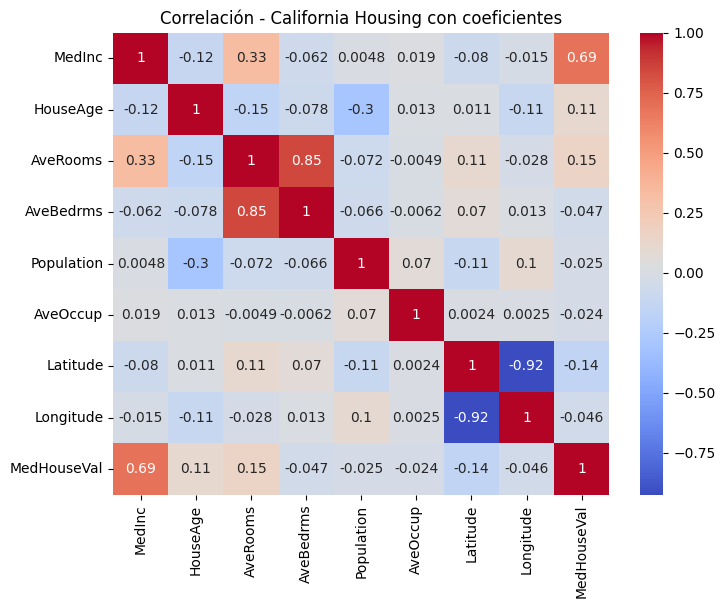

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True)
plt.title("Correlación - California Housing con coeficientes")
plt.show()

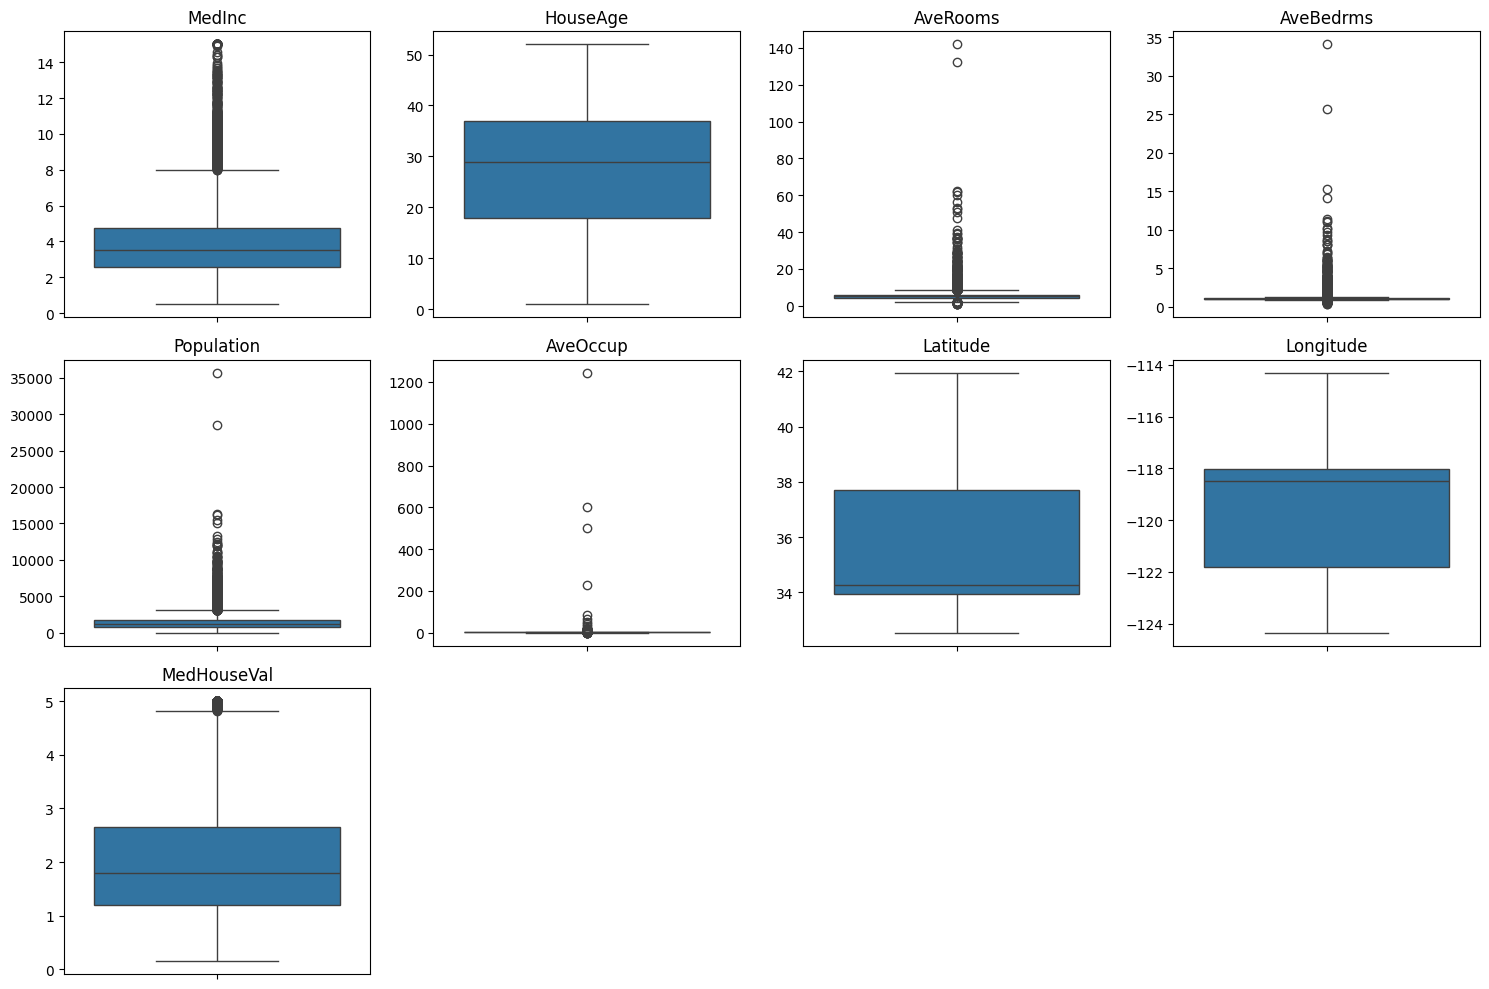

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
for i, column in enumerate(df.columns):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[column])
    plt.title(column)
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Exclude the target variable 'MedHouseVal' for VIF calculation
X = df.drop('MedHouseVal', axis=1)

# Add a constant to the DataFrame (required for VIF calculation)
X_const = add_constant(X)

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

print("Variance Inflation Factor (VIF) for each feature:")
print(vif_data.sort_values(by='VIF', ascending=False))

Variance Inflation Factor (VIF) for each feature:
      feature           VIF
0       const  17082.623698
7    Latitude      9.297624
8   Longitude      8.962263
3    AveRooms      8.342786
4   AveBedrms      6.994995
1      MedInc      2.501295
2    HouseAge      1.241254
5  Population      1.138125
6    AveOccup      1.008324


VIF de AveRooms y AveBedrms ≈ 8–15
Esto es riesgo moderado-alto

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
r2_scaled = r2_score(y_test, y_pred)

r2_scaled

0.575787706032451

In [11]:
# Elimina MedHouseVal (dependiente)
# Elimina # Bedrooms, que tiene alto VIF
X2 = df.drop(columns=['MedHouseVal', 'AveBedrms'])

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y, test_size=0.2, random_state=42)

# Initialize and fit StandardScaler for the second model
scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

lr2 = LinearRegression()
lr2.fit(X_train2_scaled, y_train2)

y_pred2 = lr2.predict(X_test2_scaled)
r2_reduced = r2_score(y_test2, y_pred2)

r2_reduced
# Se tiene un r2 marginalmente superior con una variable menos

0.5823239094526443

In [16]:
# Los coeficientes de las ecuaciones también se estabilizan
# Get coefficients and intercept for the original model (lr)
original_coefs = dict(zip(X.columns, lr.coef_))
original_coefs['const'] = lr.intercept_

# Get coefficients and intercept for the reduced model (lr2)
reduced_coefs = dict(zip(X2.columns, lr2.coef_))
reduced_coefs['const'] = lr2.intercept_

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Original Model (lr)': pd.Series(original_coefs),
    'Reduced Model (lr2)': pd.Series(reduced_coefs)
})

print(comparison_df.sort_index())

            Original Model (lr)  Reduced Model (lr2)
AveBedrms              0.339259                  NaN
AveOccup              -0.040829            -0.037483
AveRooms              -0.294410             0.045637
HouseAge               0.122546             0.123406
Latitude              -0.896929            -0.978290
Longitude             -0.869842            -0.931742
MedInc                 0.854383             0.708260
Population            -0.002308            -0.003305
const                  2.071947             2.071947


<Figure size 600x400 with 0 Axes>

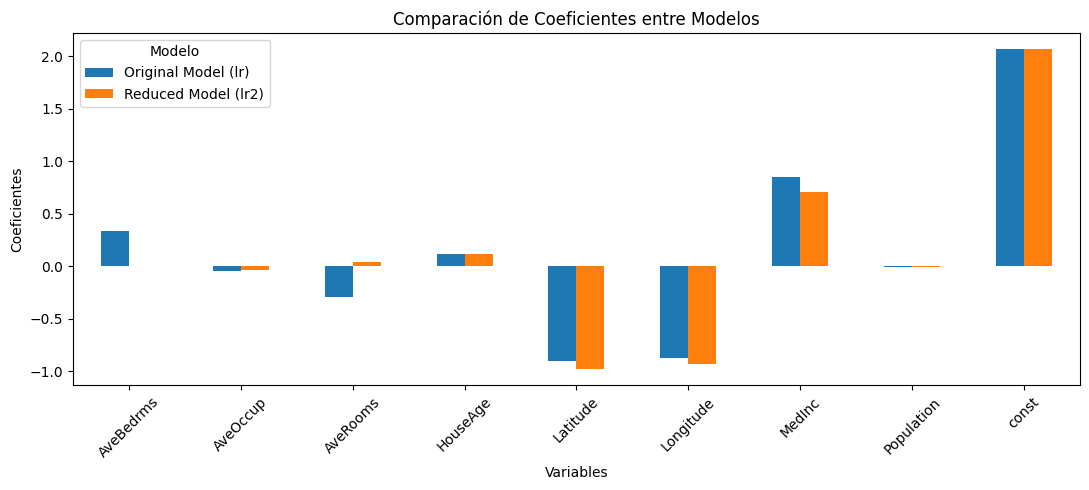

In [24]:
df_plot = comparison_df.copy()

plt.figure(figsize=(6,4))
df_plot.plot(kind="bar", figsize=(11,5))

# Plot
plt.xlabel("Variables")
plt.ylabel("Coeficientes")
plt.title("Comparación de Coeficientes entre Modelos")
plt.xticks(rotation=45)
plt.legend(title="Modelo")
plt.tight_layout()
plt.show()

Regularización con Ridge

In [25]:
from sklearn.linear_model import Ridge

# Initialize and train the Ridge Regression model with X2 data
ridge_model2 = Ridge(random_state=42)
ridge_model2.fit(X_train2_scaled, y_train2)

# Make predictions and calculate R-squared for the Ridge model with X2 data
y_pred_r2 = ridge_model2.predict(X_test2_scaled)
r2_ridge2 = r2_score(y_test2, y_pred_r2)

print(f"R-squared for Ridge Regression with X2 data: {r2_ridge2}")

R-squared for Ridge Regression with X2 data: 0.5823242676646622


In [26]:
import pandas as pd

# Get coefficients and intercept for the original model (lr)
original_coefs = dict(zip(X.columns, lr.coef_))
original_coefs['const'] = lr.intercept_

# Get coefficients and intercept for the reduced model (lr2)
reduced_coefs = dict(zip(X2.columns, lr2.coef_))
reduced_coefs['const'] = lr2.intercept_

# Get coefficients and intercept for the Ridge model (ridge_model2)
ridge_coefs = dict(zip(X2.columns, ridge_model2.coef_))
ridge_coefs['const'] = ridge_model2.intercept_

# Create a DataFrame for coefficient comparison
comparison_df_coefs = pd.DataFrame({
    'Original LR (lr)': pd.Series(original_coefs),
    'Reduced LR (lr2)': pd.Series(reduced_coefs),
    'Ridge Reg (ridge_model2)': pd.Series(ridge_coefs)
}).sort_index()

# Create a DataFrame for R2 score comparison
comparison_df_r2 = pd.DataFrame({
    'Model': ['Original LR (lr)', 'Reduced LR (lr2)', 'Ridge Reg (ridge_model2)'],
    'R2 Score': [r2_scaled, r2_reduced, r2_ridge2]
})

print("\n--- Coefficients Comparison ---\n")
print(comparison_df_coefs)

print("\n--- R2 Score Comparison ---\n")
print(comparison_df_r2.set_index('Model'))


--- Coefficients Comparison ---

            Original LR (lr)  Reduced LR (lr2)  Ridge Reg (ridge_model2)
AveBedrms           0.339259               NaN                       NaN
AveOccup           -0.040829         -0.037483                 -0.037491
AveRooms           -0.294410          0.045637                  0.045545
HouseAge            0.122546          0.123406                  0.123490
Latitude           -0.896929         -0.978290                 -0.977363
Longitude          -0.869842         -0.931742                 -0.930823
MedInc              0.854383          0.708260                  0.708345
Population         -0.002308         -0.003305                 -0.003278
const               2.071947          2.071947                  2.071947

--- R2 Score Comparison ---

                          R2 Score
Model                             
Original LR (lr)          0.575788
Reduced LR (lr2)          0.582324
Ridge Reg (ridge_model2)  0.582324


<Figure size 1200x600 with 0 Axes>

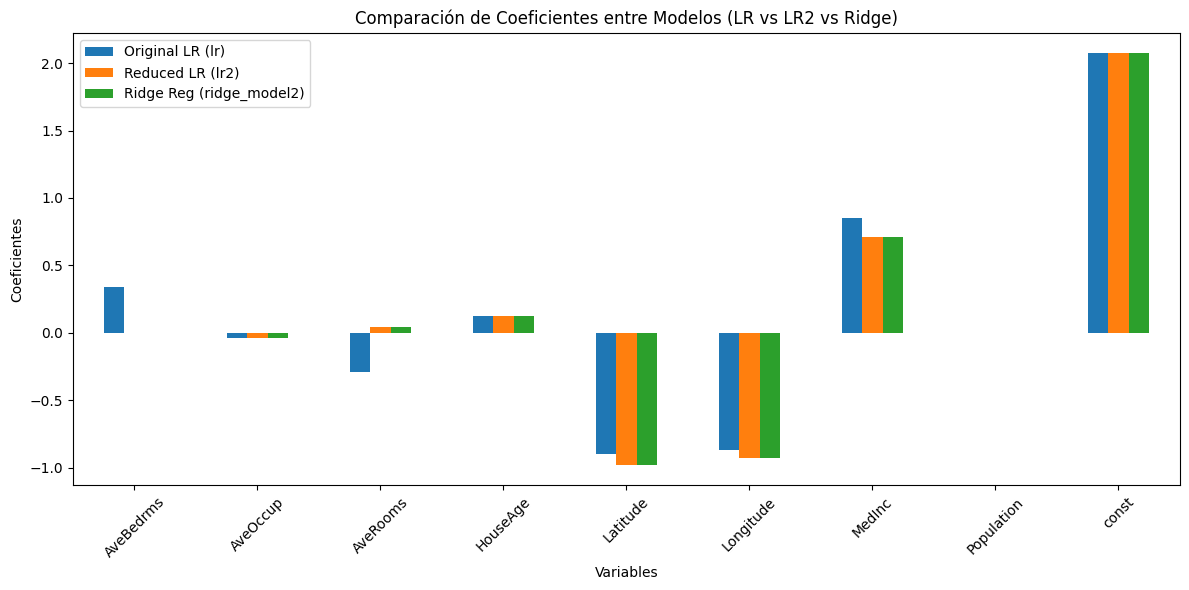

In [31]:
plt.figure(figsize=(12,6))
ax = comparison_df_coefs.plot(kind="bar", figsize=(12,6))

# Add numeric labels on each bar
#for container in ax.containers:
#    ax.bar_label(container, fmt="%.3f", padding=1)

plt.xlabel("Variables")
plt.ylabel("Coeficientes")
plt.title("Comparación de Coeficientes entre Modelos (LR vs LR2 vs Ridge)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

PCA

In [32]:
from sklearn.decomposition import PCA

pca = PCA() # Do not specify n_components to analyze all components
pca.fit(X_train_scaled)

print("PCA fitted successfully to X_train_scaled.")

PCA fitted successfully to X_train_scaled.


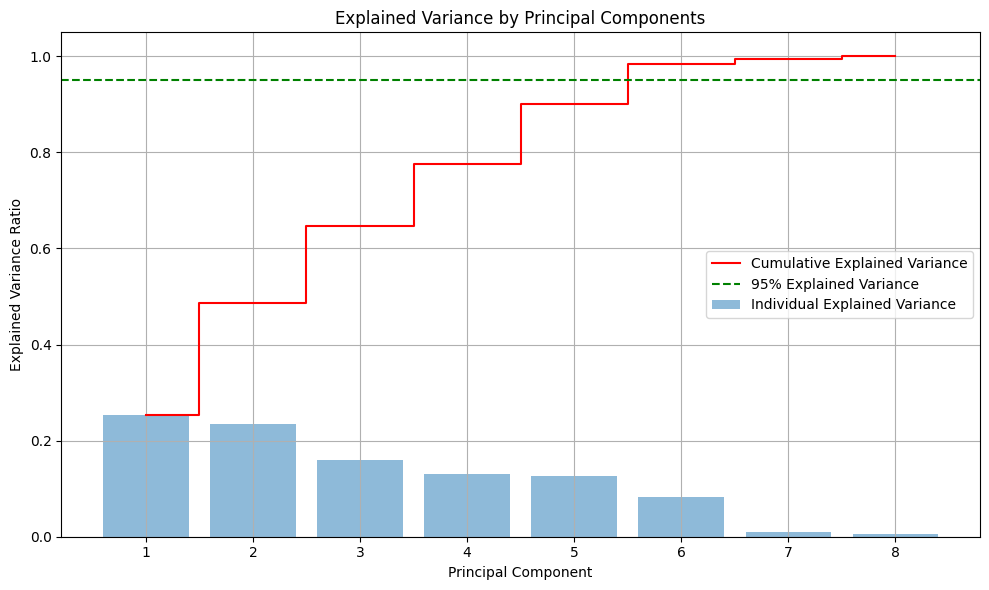

Number of components to explain 95% variance: 6


In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Get explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Create the plot
plt.figure(figsize=(10, 6))

plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.5, align='center', label='Individual Explained Variance')
plt.step(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, where='mid', label='Cumulative Explained Variance', color='red')
plt.axhline(y=0.95, color='green', linestyle='--', label='95% Explained Variance')

plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component')
plt.title('Explained Variance by Principal Components')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional: Print the number of components for 95% variance
num_components_95 = np.where(cumulative_explained_variance >= 0.95)[0][0] + 1
print(f"Number of components to explain 95% variance: {num_components_95}")

In [34]:
pca_final = PCA(n_components=7)
pca_final.fit(X_train_scaled)

X_train_pca = pca_final.transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

print("Data transformed using PCA with 7 components.")

Data transformed using PCA with 7 components.


**Reasoning**:
Now that the data has been transformed using PCA, I will train a Linear Regression model on the `X_train_pca` and `y_train` datasets and then evaluate its performance using `r2_score` on the `X_test_pca` and `y_test` datasets. This will allow for comparison with previously calculated R-squared scores.



In [35]:
lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)

y_pred_pca = lr_pca.predict(X_test_pca)
r2_pca = r2_score(y_test, y_pred_pca)

print(f"R-squared for Linear Regression with PCA components: {r2_pca}")

R-squared for Linear Regression with PCA components: 0.5548572950064063


**Reasoning**:
To provide a comprehensive comparison, I will create a pandas DataFrame that consolidates the R-squared scores from all models: the original linear regression (`r2_scaled`), the reduced linear regression (`r2_reduced`), the Ridge regression (`r2_ridge2`), and the new PCA-based linear regression (`r2_pca`). Then, I will print this DataFrame.



In [ ]:
import pandas as pd

# Create a DataFrame for R2 score comparison, including the PCA model
comparison_df_r2_all = pd.DataFrame({
    'Model': ['Original LR (lr)', 'Reduced LR (lr2)', 'Ridge Reg (ridge_model2)', 'PCA LR (lr_pca)']
})

# Append R2 scores to the DataFrame
comparison_df_r2_all['R2 Score'] = [r2_scaled, r2_reduced, r2_ridge2, r2_pca]

print("\n--- Comprehensive R2 Score Comparison ---\n")
print(comparison_df_r2_all.set_index('Model'))


--- Comprehensive R2 Score Comparison ---

                          R2 Score
Model                             
Original LR (lr)          0.576074
Reduced LR (lr2)          0.581804
Ridge Reg (ridge_model2)  0.581804
PCA LR (lr_pca)           0.490061
